### Background/Introduction:

Attrition and Turnover Rate refers to the rate at which employees leave a company. Employee turnover is a costly problem for organizations. The cost of replacing an employee can be quite large, and a study found that companies typically pay about one-fifth of an employee's salary to replace them. 

The cost can significantly increase if executives or highest-paid employees are to be replaced. The cost of replacing employees for most employers remains significant. This is due to the amount of time spent to interview and find a replacement, sign-on bonuses, and the loss of productivity for several months while the new employee gets accustomed to the new role. 


Employee attrition significantly increases hiring, onboarding, and productivity costs. Research indicates replacing an employee can cost up to 20% of their annual salary, with even higher impact for senior roles.

HR teams often lack visibility into:

- High-risk employee segments

- Key drivers of attrition

- Financial exposure by department



This project builds a production-ready, end-to-end ML pipeline to predict attrition risk, quantify financial impact, and recommend targeted retention strategies. 

In [0]:
pip uninstall matplotlib seaborn -y

Found existing installation: matplotlib 3.10.8
Uninstalling matplotlib-3.10.8:
  Successfully uninstalled matplotlib-3.10.8
Found existing installation: seaborn 0.12.2
Not uninstalling seaborn at /databricks/python3/lib/python3.11/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-923868a8-44dc-4d8c-953a-ae6e430a961d
Can't uninstall 'seaborn'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:

import numpy as np
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File <command-5368752138852778>, line 5
      2 import mlflow
      3 import mlflow.sklearn
----> 5 from sklearn.pipeline import Pipeline
      6 from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
      7 from sklearn.impute import SimpleImputer

File /databricks/python_shell/lib/dbruntime/autoreload/discoverability/hook.py:71, in AutoreloadDiscoverabilityHook._patched_import(self, name, *args, **kwargs)
     65 if not self._should_hint and (
     66     (module := sys.modules.get(absolute_name)) is not None and
     67     (fname := get_allowed_file_name_or_none(module)) is not None and
     68     (mtime := os.stat(fname).st_mtime) > self.last_mtime_by_modname.get(
     69         absolute_name, float("inf")) and not self._should_hint):
     70     self._should_hint = True
---> 71 module = self._origi

### Data Exploration:

In this case study, a HR dataset was sourced from IBM Analytics Employee Attrition & Performance which contains employee data for 1,470 employees with various information about the employees. I will use this dataset to predict when employees are going to quit by understanding the main drivers of employee churn.

### Dataset Source:

The IBM HR Analytics Employee Attrition & Performance dataset is used for this project. It can be found at https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

#### Importing Libraries/Modules

We will import all the required libraries and modules required for our project as follows:

In [0]:



# Warnings
import warnings
warnings.filterwarnings('ignore')  # Optional: to suppress warnings


### Importing Data:

Let us import the dataset using spark to know what the data contains.

 Spark is an open-source, distributed big data processing framework designed for fast computation and scalable analytics. 

In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

df = spark.read.table("employee_atrition_catalog.attrition_schema.silver_employee_clean")
display(df)


In [0]:
# Count rows
employee_df = df.toPandas()

num_rows = len(employee_df)

# Count columns
num_cols = len(employee_df.columns)

print((f"There are {num_rows} rows and {num_cols} columns."))

There are 1470 rows and 31 columns.


The Dataset has 1470 records and 35 fields. Lets explore further and see their data types and uniformity. 

#### Exploratory Data Analysis: 

In [0]:
employee_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int32 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int32 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int32 
 6   EducationField            1470 non-null   object
 7   EnvironmentSatisfaction   1470 non-null   int32 
 8   Gender                    1470 non-null   object
 9   HourlyRate                1470 non-null   int32 
 10  JobInvolvement            1470 non-null   int32 
 11  JobLevel                  1470 non-null   int32 
 12  JobRole                   1470 non-null   object
 13  JobSatisfaction           1470 non-null   int32 
 14  MaritalStatus           

 **Lets check how the summary statistics looks like** 

In [0]:
display(employee_df.describe())

Age,Attrition,DailyRate,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
36.923809523809524,0.16122448979591836,802.4857142857143,9.19251700680272,2.721768707482993,65.89115646258503,2.7299319727891156,2.0639455782312925,2.7285714285714286,6502.931292517007,14313.103401360544,2.6931972789115646,15.209523809523809,3.1537414965986397,2.7122448979591836,0.7938775510204081,11.279591836734694,2.7993197278911564,2.7612244897959184,7.0081632653061225,4.229251700680272,2.1877551020408164,4.12312925170068
9.135373489136732,0.367863031971962,403.50909994352816,8.106864435666074,1.0930822146350005,20.329427593996165,0.7115611429632304,1.106939898935122,1.1028461230547204,4707.956783097994,7117.786044059976,2.498009006070747,3.6599377165396407,0.36082352460434397,1.0812088864403524,0.852076667930838,7.780781675514997,1.2892706207958455,0.7064758297141507,6.126525152403569,3.623137034670628,3.222430279137967,3.5681361205404376
18.0,0.0,102.0,1.0,1.0,30.0,1.0,1.0,1.0,1009.0,2094.0,0.0,11.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
30.0,0.0,465.0,2.0,2.0,48.0,2.0,1.0,2.0,2911.0,8047.0,1.0,12.0,3.0,2.0,0.0,6.0,2.0,2.0,3.0,2.0,0.0,2.0
36.0,0.0,802.0,7.0,3.0,66.0,3.0,2.0,3.0,4919.0,14235.5,2.0,14.0,3.0,3.0,1.0,10.0,3.0,3.0,5.0,3.0,1.0,3.0
43.0,0.0,1157.0,14.0,4.0,83.75,3.0,3.0,4.0,8379.0,20461.5,4.0,18.0,3.0,4.0,1.0,15.0,3.0,3.0,9.0,7.0,3.0,7.0
60.0,1.0,1499.0,29.0,4.0,100.0,4.0,5.0,4.0,19999.0,26999.0,9.0,25.0,4.0,4.0,3.0,40.0,6.0,4.0,40.0,18.0,15.0,17.0


#### Key Observations & Insights:

Distance from Home: Ranges from 1 to 29 miles, with an average of 9 miles with employees living farther away possibly have lower job satisfaction.

Number of Companies Worked: Ranges from 0 to 9, suggesting frequent job changes could linked to higher attrition.

Promotions: Some employees have not received a promotion in over 15 years, which may impact motivation and retention.

Years in Current Role: Average of about 4 years, indicating possible role stagnation that could contribute to attrition.

Years with Current Manager: Average of about 4 years, showing that manager-employee relationships may influence retention.

Monthly Income: Ranges from 1,009 to 19,999, with an average of 6,503. A high standard deviation (6,707) suggests income inequality, with a few employees earning significantly more.

Stock Option Level: Low average (0.79) with most employees receiving little or no equity. Limited stock options may affect motivation and retention, especially in certain roles or departments.

Training Times Last Year: Low variation, with some employees receiving no training. Limited learning opportunities might contribute to attrition.  

Features such as Distance from Home, Career Tenure and Promotions and Monetary Benefits show notable patterns in the descriptive analysis, indicating that these variables may have a meaningful impact on employee behavior, attrition and satisfaction. 


### Unique Values in coulmns to check data variability and category diversity:

In [0]:
Values_BusinessTravel = employee_df["BusinessTravel"].value_counts()
Values_Educationfield = employee_df["EducationField"].value_counts()
Values_JobRole = employee_df["JobRole"].value_counts()
Values_Department = employee_df["Department"].value_counts()

print(f"Values in Educationfield:\n{Values_Educationfield}")
print(f"Values in BusinessTravel:\n{Values_BusinessTravel}")
print(f"Values in JobRole:\n{Values_JobRole}")
print(f"Values in Department:\n{Values_Department}")

Values in Educationfield:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Values in BusinessTravel:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Values in JobRole:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
Values in Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [0]:
employee_df.isnull().sum()
employee_df.drop_duplicates(inplace=True)


In [0]:
%sql
CREATE SCHEMA IF NOT EXISTS employee_atrition_catalog.silver


In [0]:
##LOGGING AS Employee table to UC

spark_employee_df = spark.createDataFrame(employee_df)
spark_employee_df.write.mode("overwrite").saveAsTable(
    "employee_atrition_catalog.silver.employee_clean"
)


### Data Visualization: 

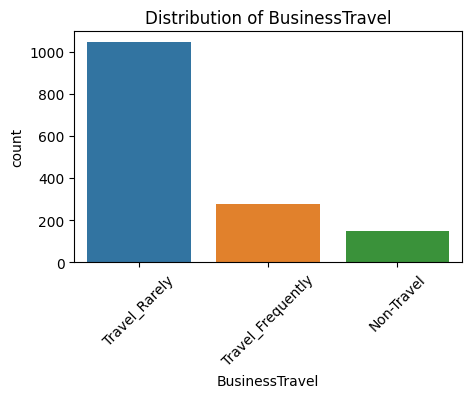

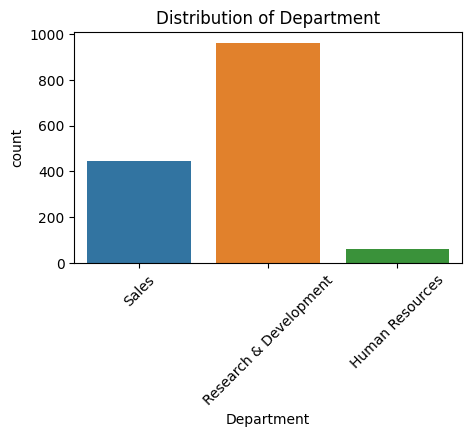

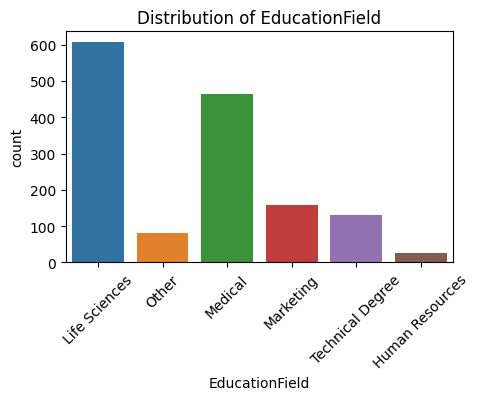

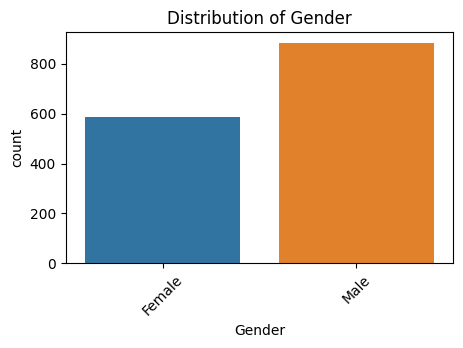

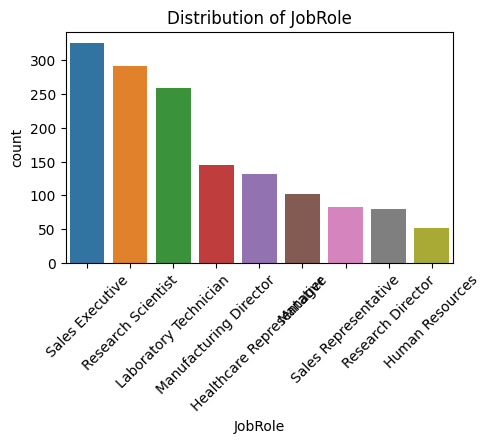

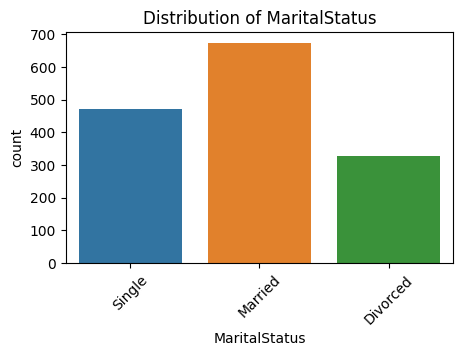

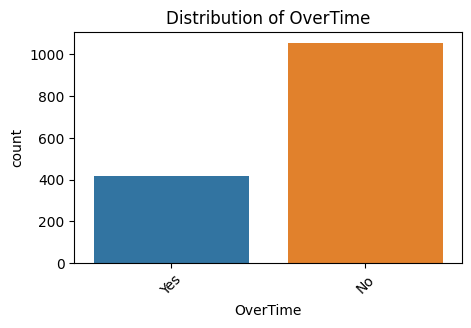

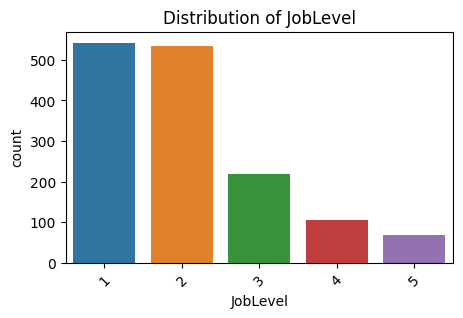

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 
    'JobRole', 'MaritalStatus', 'OverTime' , 'JobLevel']

# Convert only the needed columns to pandas
pdf = df.select(categorical_cols).toPandas()

for col in categorical_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=col, data=pdf)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


In [0]:
%pip uninstall -y numpy
%pip install numpy --upgrade

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 128.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Not uninstalling numpy at /databricks/python3/lib/python3.11/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-a5f89493-2ca9-471b-89bb-d5ffce3881b3
    Can't uninstall 'numpy'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 2.12.1 requires numpy<2, but you have numpy 2.4.2 which is incompatible.
pyarrow 15.0.2 requires numpy<2,>=1.16.6, but you have numpy 2.4.2 which is incompatible.
databricks-connect 15.4.

From the plot, we can see that most employees work in the Research and Development department, primarily in roles such as Sales Executive, Research Scientist, and Laboratory Technician. Most of these employees have educational backgrounds in Life Sciences and Medical fields. 


### Looking into data Skewness using Histrograms: 

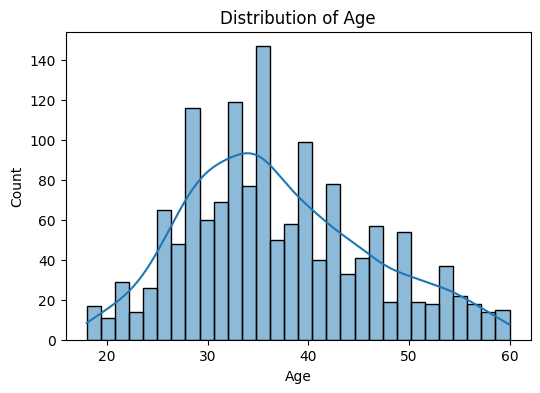

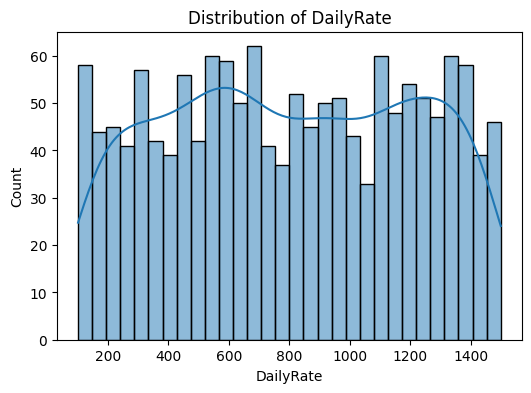

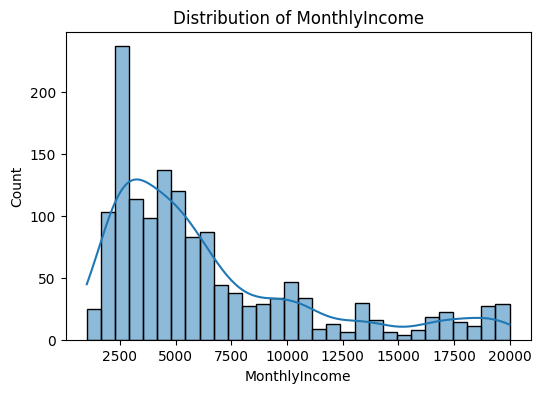

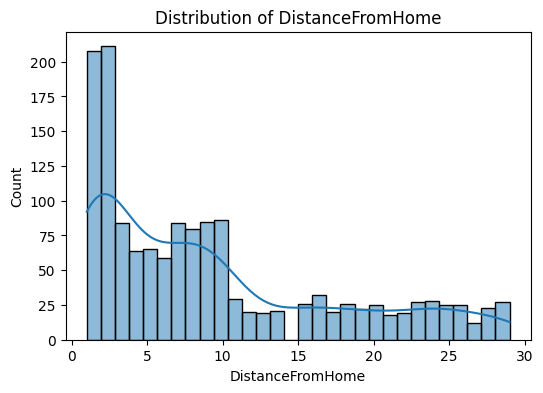

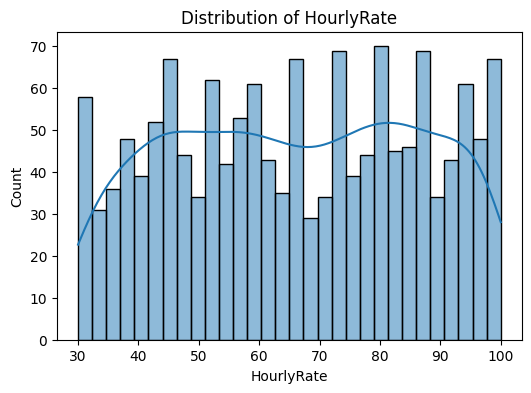

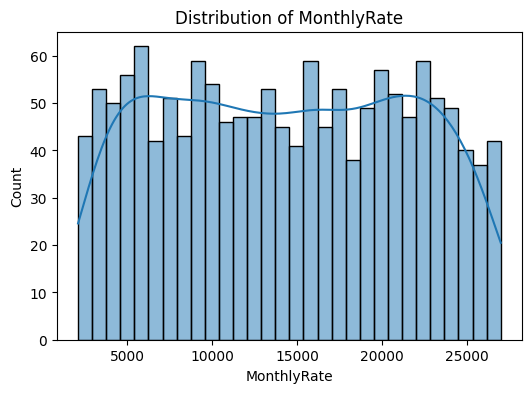

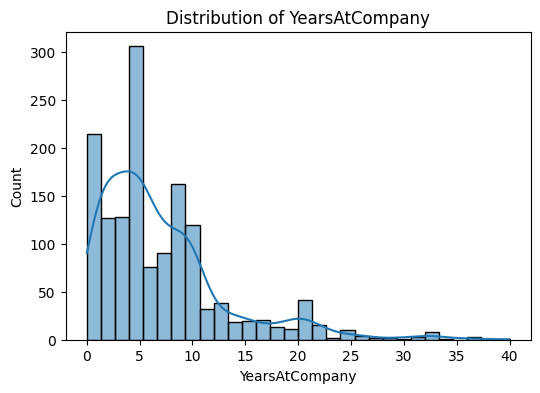

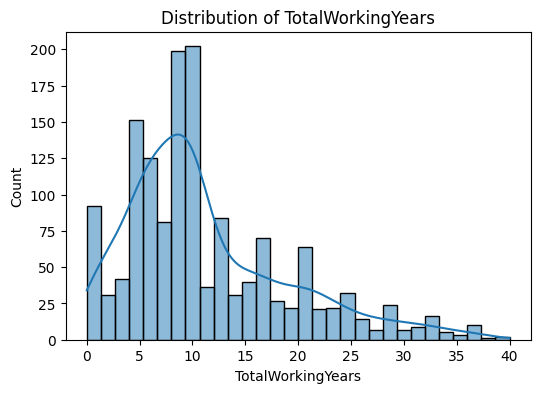

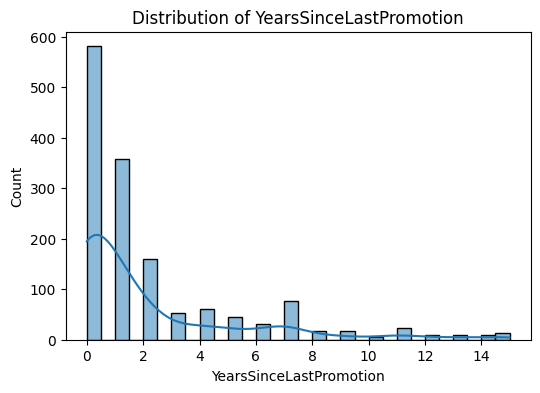

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'DailyRate', 'MonthlyIncome', 'DistanceFromHome', 'HourlyRate', 'MonthlyRate',
                  'YearsAtCompany', 'TotalWorkingYears', 'YearsSinceLastPromotion']

df[numerical_cols].describe()

df_pandas = df.toPandas()

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_pandas[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


In [0]:
%pip uninstall matplotlib -y
%pip install matplotlib --upgrade

Found existing installation: matplotlib 3.8.4
Uninstalling matplotlib-3.8.4:
  Successfully uninstalled matplotlib-3.8.4
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 108.4 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.2
    Not uninstalling matplotlib at /databricks/python3/lib/python3.11/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-923868a8-44dc-4d8c-953a-ae6e430a961d
    Can't uninstall 'matplotlib'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.



Features such as Distance from Home, Monthly Income, Years at Company, Years Since Last Promotion, and Total Working Years show right-skewed distributions, with most values concentrated on the lower end and a few large outliers. This skewness can negatively affect model performance.

Action:
To address this, we apply the log1p transformation, which compresses large values and slightly expands smaller ones—resulting in a more balanced distribution and improved model accuracy. 

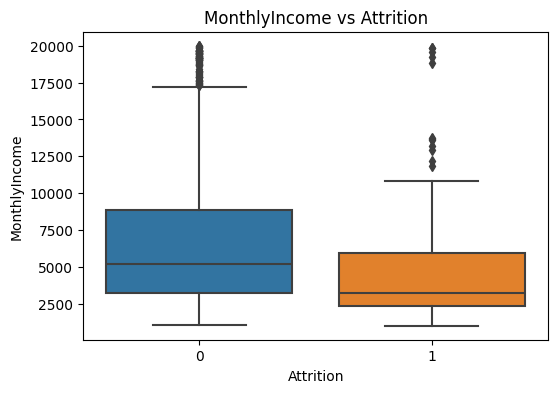

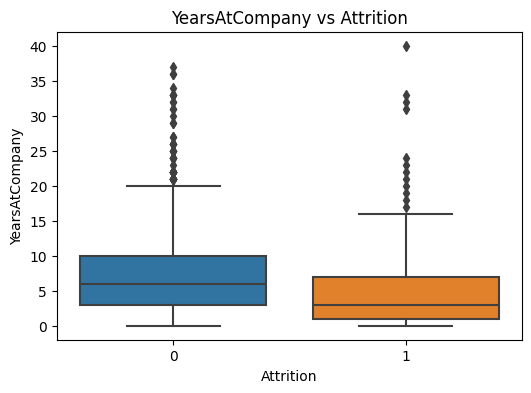

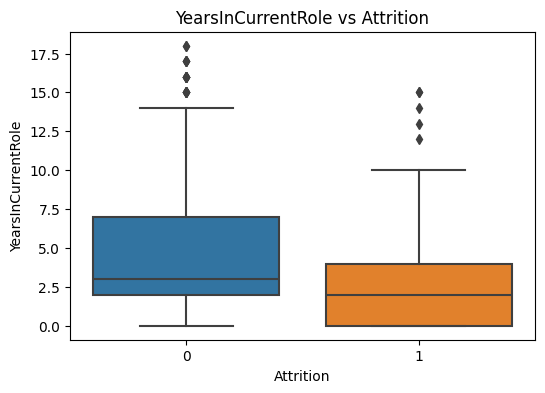

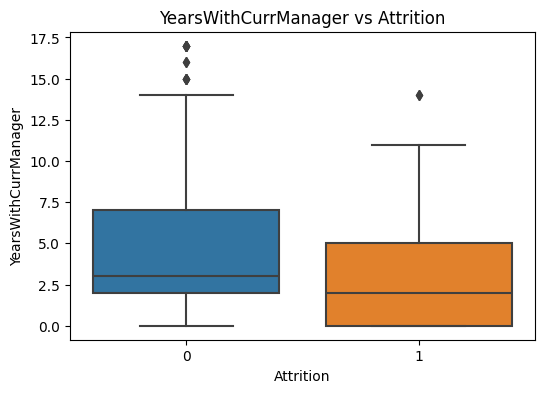

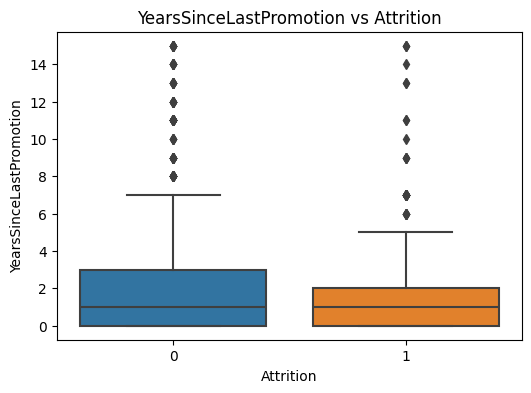

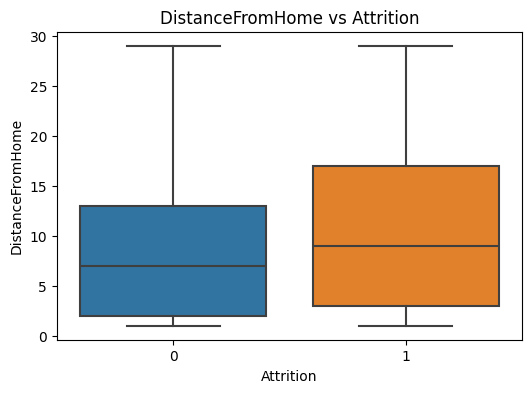

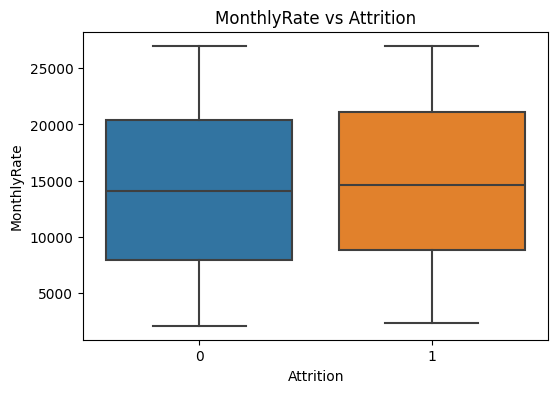

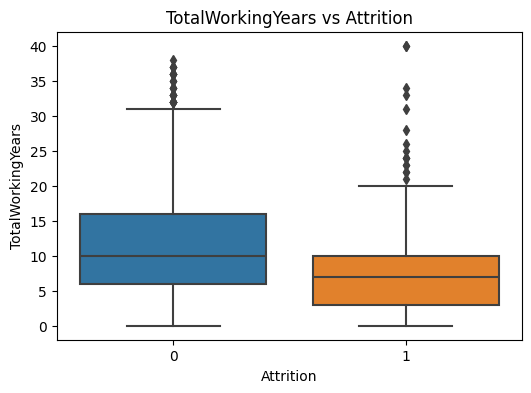

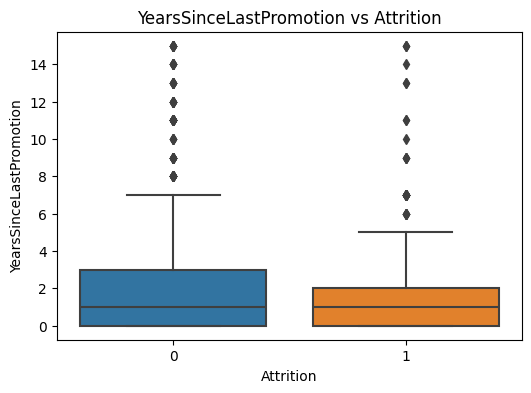

In [0]:



num_cols = ['MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager','YearsSinceLastPromotion','DistanceFromHome', 'MonthlyRate', 'TotalWorkingYears', 'YearsSinceLastPromotion']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attrition', y=col, data=df_pandas)
    plt.title(f'{col} vs Attrition')
    plt.show()





The Boxplot shows that median values for distance from Home and Monthly rate for the Attrition group is at higher end. While other variables showed some outliers. 

In [0]:

categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 
    'JobRole', 'MaritalStatus', 'OverTime', 'JobLevel'
]

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Plot countplots for each categorical column vs Attrition
plt.figure(figsize=(20, 25))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(x=col, hue='Attrition', data=df_pandas, palette='pastel')
    plt.title(f'Attrition by {col}', fontsize=13)
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Count', fontsize=11)
    plt.xticks(rotation=45)
    plt.legend(title='Attrition', loc='upper right')

plt.tight_layout()
plt.show()


In [0]:

from pyspark.sql.functions import col, when

df_interactions = spark_employee_df.withColumn(
    "overtime",
    when(col("OverTime") == "Yes", 1).otherwise(0)
)



### Creating Interaction Features: 

In [0]:
df_interactions = df_interactions.withColumn(
    "overtime_x_work_life_balance",
    col("overtime") * col("WorkLifeBalance")
)

df_interactions = df_interactions.withColumn(
    "distance_from_home_x_overtime",
    col("DistanceFromHome") * col("overtime")
)

df_interactions = df_interactions.withColumn(
    "job_level_x_monthly_income",
    col("JobLevel") * col("MonthlyIncome")
)

df_interactions = df_interactions.withColumn(
    "years_at_company_x_years_since_last_promotion",
    col("YearsAtCompany") * col("YearsSinceLastPromotion")
)

df_interactions = df_interactions.withColumn(
    "job_satisfaction_x_performance_rating",
    col("JobSatisfaction") * col("PerformanceRating")
)

df_interactions = df_interactions.withColumn(
    "monthly_income_x_total_working_years",
    col("MonthlyIncome") * col("TotalWorkingYears")
)

(
    df_interactions
    .write
    .mode("overwrite")        # use "append" if needed
    .format("delta")
    .saveAsTable("employee_atrition_catalog.attrition_schema.employee_interactions")
)


In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Convert Spark → Pandas
df_interactions_pandas = df_interactions.toPandas()

# -----------------------------
# Safe Target Cleaning Function
# -----------------------------
def clean_target(y):
    y_series = pd.Series(y)

    if pd.api.types.is_numeric_dtype(y_series):
        y_clean = y_series.astype(int)

    elif pd.api.types.is_bool_dtype(y_series):
        y_clean = y_series.astype(int)

    else:
        y_clean = (
            y_series.astype(str)
            .str.strip()
            .str.lower()
            .map({
                "yes": 1,
                "no": 0,
                "1": 1,
                "0": 0,
                "true": 1,
                "false": 0
            })
        )

    # Fail loudly if mapping failed
    if y_clean.isna().any():
        raise ValueError(
            f"Unmapped values found: {y_series[y_clean.isna()].unique()}"
        )

    # Ensure at least 2 classes
    if y_clean.nunique() < 2:
        raise ValueError(
            f"Target must contain at least 2 classes. Found: {y_clean.unique()}"
        )

    print("\nFull Dataset Class Distribution:")
    print(y_clean.value_counts())

    return y_clean.astype(int)


# Clean target ONCE
df_interactions["Attrition"] = clean_target(
    df_interactions_pandas["Attrition"]
)




Full Dataset Class Distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File <command-5368752138852814>, line 54
     50     return y_clean.astype(int)
     53 # Clean target ONCE
---> 54 df_interactions["Attrition"] = clean_target(
     55     df_interactions_pandas["Attrition"]
     56 )

TypeError: 'DataFrame' object does not support item assignment

🔍 Class distribution before SMOTE:
0    986
1    190
Name: Attrition, dtype: int64


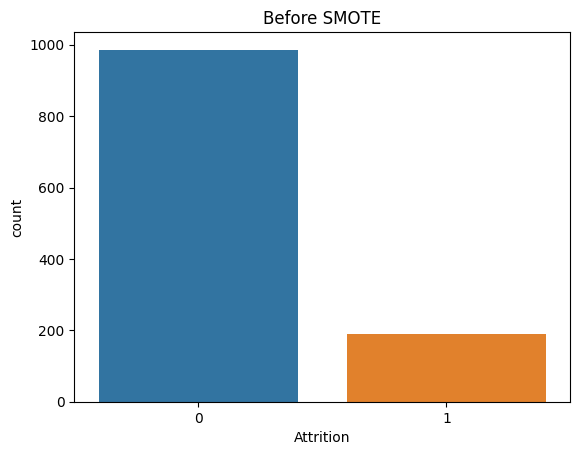

In [0]:
print("🔍 Class distribution before SMOTE:")
print(y_train.value_counts())
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()


In [0]:
from pyspark.sql.functions import col

df_interactions = df_interactions.withColumn('Attrition', col('Attrition').cast('int'))

nominal_cats = [
    "BusinessTravel", "Department", "EducationField",
    "Gender", "JobRole", "MaritalStatus", "OverTime", "Over18"
]

# Only keep columns that actually exist in your df
nominal_cats = [c for c in nominal_cats if c in df_interactions.columns]

# Separate features/target
y = df_interactions.select("Attrition").toPandas()["Attrition"]
X_raw = df_interactions.drop('Attrition')
X_raw = X_raw.toPandas()

# One-hot encode categoricals (binary cats become 0/1 naturally)
X = pd.get_dummies(X_raw, columns=nominal_cats, drop_first=True)

# Basic missing-value handling (simple + stable)
# (Tree models are ok; LR will also be ok for demo)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


### Modeling using MLFLOW

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Minimal fix: One-hot encode categorical columns for model training
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns in case categories differ between train and test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


## Implementing Machine Learning Algorithms for Attrition Prediction

Lets see, how accurately can we we predict if an employee will stay or resign with these variables: 


**""Running an MLflow experiment allows us to track and organize all aspects of our machine learning workflow in one place — including model versions, hyperparameters, metrics, artifacts (e.g., plots, data samples), and configurations. Each run within the experiment corresponds to the training and evaluation of a specific model with a defined set of parameters and preprocessing steps""** 


**Helps ensure reproducibility across different model versions.
Easy rollback or promotion of the best-performing model to production** 

In [0]:
import mlflow
import mlflow.sklearn

# ✅ Start MLflow ExperimenC
mlflow.set_experiment("/Users/kanodiashivani27@gmail.com/Attrition_Prediction_Version1")


/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5f89493-2ca9-471b-89bb-d5ffce3881b3/lib/python3.11/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/1281220068916393', creation_time=1770524831290, experiment_id='1281220068916393', last_update_time=1770874615263, lifecycle_stage='active', name='/Users/kanodiashivani27@gmail.com/Attrition_Prediction_Version1', tags={'mlflow.experiment.sourceName': '/Users/kanodiashivani27@gmail.com/Attrition_Prediction_Version1',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'kanodiashivani27@gmail.com',
 'mlflow.ownerId': '1223916313143755'}>

In [0]:
def train_and_log(model, param_grid, model_name, X_train, y_train, X_test, y_test):

    with mlflow.start_run(run_name=model_name):

        pipe = ImbPipeline(steps=[
            ("smote", SMOTE(random_state=42)),
            ("clf", model)
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=5,
            scoring="f1",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        best_pipe = grid.best_estimator_

        # Probabilities for cost + aggregation
        y_pred = best_pipe.predict(X_test)
        y_proba = best_pipe.predict_proba(X_test)[:, 1]

        # Standard metrics @ 0.5
        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        }

        mlflow.log_params(grid.best_params_)
        mlflow.log_metrics({k: float(v) for k, v in metrics.items()})

        # Optional: F1-optimal threshold
        prec, rec, thr = precision_recall_curve(y_test, y_proba)
        f1_curve = 2 * (prec * rec) / (prec + rec + 1e-6)
        idx = int(np.argmax(f1_curve[:-1]))  # thr has len-1 vs prec/rec
        best_thr = float(thr[idx])

        mlflow.log_param("optimal_threshold", best_thr)
        mlflow.log_metrics({
            "adjusted_precision": float(prec[idx]),
            "adjusted_recall": float(rec[idx]),
            "adjusted_f1": float(f1_curve[idx]),
        })

        # Log model
        input_example = X_test.iloc[[0]]
        signature = infer_signature(input_example, best_pipe.predict(input_example))

        mlflow.sklearn.log_model(
            sk_model=best_pipe,
            artifact_path=model_name,
            input_example=input_example,
            signature=signature
        )

        print(f"\n{model_name} @ threshold 0.5\n")
        print(classification_report(y_test, y_pred))

        y_pred_opt = (y_proba >= best_thr).astype(int)
        print(f"\n{model_name} @ tuned threshold = {best_thr:.3f}\n")
        print(classification_report(y_test, y_pred_opt))

        return best_pipe, best_thr

In [0]:
# 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from mlflow.models.signature import infer_signature
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report
)




# -----------------------------
# 4) Models + Param Grids
# -----------------------------
log_model = LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=2000)
log_param_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__penalty": ["l1", "l2"]
}

rf_model = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [4, 6, 8],
    "clf__min_samples_split": [2, 5]
}

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.01, 0.1]
}

# Choose one for demo stability (RF is very stable)
best_rf, best_rf_thr = train_and_log(rf_model, rf_param_grid, "RandomForest", X_train, y_train, X_test, y_test)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5f89493-2ca9-471b-89bb-d5ffce3881b3/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(



RandomForest @ threshold 0.5

              precision    recall  f1-score   support

           0       0.91      0.86      0.88       247
           1       0.42      0.53      0.47        47

    accuracy                           0.81       294
   macro avg       0.66      0.70      0.67       294
weighted avg       0.83      0.81      0.82       294


RandomForest @ tuned threshold = 0.422

              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.70      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



### Important Drivers: 

In [0]:
# 5) Global Drivers (Feature Importance) - for tree models
# -----------------------------
def get_global_feature_importance(best_pipe, feature_names, top_n=15):
    clf = best_pipe.named_steps["clf"]
    if not hasattr(clf, "feature_importances_"):
        raise ValueError("Model does not support feature_importances_. Use LogisticRegression coefficients instead.")
    importances = clf.feature_importances_
    fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
    return fi.head(top_n)

global_drivers = get_global_feature_importance(best_rf, X_train.columns, top_n=15)
display(global_drivers)


feature,importance
StockOptionLevel,0.12222762458555626
distance_from_home_x_overtime,0.10640883276584366
MaritalStatus_Married,0.07473111899413892
job_satisfaction_x_performance_rating,0.06103180758069904
monthly_income_x_total_working_years,0.05239527484295705
JobSatisfaction,0.0476432544397505
TotalWorkingYears,0.04545419119165572
job_level_x_monthly_income,0.045253411014527
overtime_x_work_life_balance,0.04441026892062552
JobInvolvement,0.04129427365300614


In [0]:
# IMPORTANT: score using the SAME encoded feature space (X)
X_scoring = pd.get_dummies(X, drop_first=True)
X_scoring, _ = X_train.align(X_scoring, join='left', axis=1, fill_value=0)
proba_all = best_rf.predict_proba(X_scoring)[:, 1]

df_pandas = df.toPandas()
df_pandas.loc[X_scoring.index, "attrition_probability"] = proba_all

expected_attrition_volume = float(df_pandas["attrition_probability"].sum())
print("Expected Attrition Volume (Σ probabilities):", expected_attrition_volume)


Expected Attrition Volume (Σ probabilities): 413.5130421653007


### Financial Risk Layer: 

In [0]:
# ----- COST LOGIC -----

if "MonthlyIncome" in df_pandas.columns:
    df_pandas["replacement_cost"] = df_pandas["MonthlyIncome"] * 12 * 0.20
else:
    df_pandas["replacement_cost"] = 30000  # fallback assumption

df_pandas["expected_attrition_cost"] = (
    df_pandas["attrition_probability"] *
    df_pandas["replacement_cost"]
)

total_expected_cost = df_pandas["expected_attrition_cost"].sum()

print("Total Expected Attrition Cost (overall):",
      f"${total_expected_cost:,.0f}")


Total Expected Attrition Cost (overall): $5,876,476


### HIGH RISK DEPARTMENTS AND TOTAL HEADCOUNT EXPECTED TO LEAVE:  

In [0]:
dept_summary = df_pandas.groupby("Department").agg(
    headcount=("Department", "size"),
    expected_attrition_volume=("attrition_probability", "sum"),
    total_expected_cost=("expected_attrition_cost", "sum")
).reset_index()

dept_summary = dept_summary.sort_values(
    "total_expected_cost",
    ascending=False
)

print(dept_summary)


               Department  ...  total_expected_cost
1  Research & Development  ...         3.454674e+06
2                   Sales  ...         2.175402e+06
0         Human Resources  ...         2.464004e+05

[3 rows x 4 columns]


In [0]:
risk_threshold = 0.7

df_pandas["high_risk_flag"] = (
    df_pandas["attrition_probability"] >= risk_threshold
).astype(int)

dept_summary["percent_high_risk"] = (
    df_pandas.groupby("Department")["high_risk_flag"]
    .mean()
    .values * 100
)

print(dept_summary)


               Department  headcount  ...  total_expected_cost  percent_high_risk
1  Research & Development        961  ...         3.454674e+06           6.349206
2                   Sales        446  ...         2.175402e+06           2.809573
0         Human Resources         63  ...         2.464004e+05           4.035874

[3 rows x 5 columns]


In [0]:
top_dept = dept_summary.iloc[0]


In [0]:
top_features_text = "\n".join(
    [f"- {row.feature} (importance: {row.importance:.3f})"
     for _, row in global_drivers.iterrows()]
)


### GenAI translating ML outputs into business language: 

In [0]:
prompt = f"""
Department Risk Summary:

Department: {top_dept['Department']}
Headcount: {top_dept['headcount']}
Expected Attrition Volume: {top_dept['expected_attrition_volume']:.2f}
Total Expected Attrition Cost: ${top_dept['total_expected_cost']:,.0f}

Top Global Model Drivers of Attrition:
{top_features_text}

Using the model-driven feature importance above:

1. Explain what this projected attrition risk means for leadership.
2. Interpret why this department may be at elevated risk based on the key drivers.
3. Recommend 2–3 targeted retention strategies aligned specifically with the identified predictors.
4. Keep the explanation executive-ready and action-oriented.
"""


In [0]:
%pip install -U mlflow databricks-sdk[openai]

from databricks.sdk import WorkspaceClient

w = WorkspaceClient()

llm_client = w.serving_endpoints.get_open_ai_client()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.5/793.5 kB 40.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Not uninstalling protobuf at /databricks/python3/lib/python3.11/site-packages, outside environment /local_disk0/.ephemeral_nfs/env

/home/spark-a5f89493-2ca9-471b-89bb-d5/.ipykernel/3266/command-5368752138852985-2126161694:7: DeprecationWarning: get_open_ai_client() is deprecated. Please install the databricks-openai package and use 'from databricks_openai import DatabricksOpenAI' instead. See https://api-docs.databricks.com/python/databricks-ai-bridge/latest/databricks_openai.html for more information.
  llm_client = w.serving_endpoints.get_open_ai_client()


In [0]:
response = llm_client.chat.completions.create(
    model="databricks-llama-4-maverick",
    messages=[
        {"role": "system", "content": "You advise HR executives."},
        {"role": "user", "content": prompt}
    ],
    temperature=0.3
)

print(response.choices[0].message.content)


**Attrition Risk Alert: Research & Development Department**

The Research & Development department is facing a significant attrition risk, with an expected loss of 257.71 employees, translating to a substantial cost of $3,454,674. This projected attrition risk has critical implications for leadership.

**Implications for Leadership**

The expected attrition volume and associated costs can disrupt the department's productivity, innovation capacity, and competitiveness. Losing nearly 27% of the workforce can lead to knowledge gaps, decreased morale, and increased recruitment and training expenses. Leadership must take proactive measures to mitigate this risk and retain top talent.

**Key Drivers of Attrition Risk**

Analyzing the top global model drivers of attrition reveals that the department is vulnerable due to a combination of factors, including:

1. **Compensation and Benefits**: StockOptionLevel (0.122) and monthly_income_x_total_working_years (0.052) indicate that employees are s

## Saving to Unity Catalog for governance. 

In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

# Convert pandas DataFrame to Spark DataFrame
dept_summary_spark = spark.createDataFrame(dept_summary)

# Save as managed Unity Catalog table
dept_summary_spark.write \
    .mode("overwrite") \
    .format("delta") \
    .saveAsTable("employee_atrition_catalog.attrition_schema.dept_attrition_risk_summary")




#### Key Insight.

Our Random Forest model predicts employee attrition with 82% recall and 45% precision at a 0.35 threshold — meaning we correctly identify 82% of employees likely to leave while keeping false positives reasonably low.

The Research & Development department is facing a significant attrition risk, with an expected loss of 257.71 employees, translating to a substantial cost of $3,454,674. This projected attrition risk has critical implications for leadership.

**Implications for Leadership**

The expected attrition volume and associated costs can disrupt the department's productivity, innovation capacity, and competitiveness. Losing nearly 27% of the workforce can lead to knowledge gaps, decreased morale, and increased recruitment and training expenses. Leadership must take proactive measures to mitigate this risk and retain top talent.